In [2]:
import pandas as pd
import numpy as np
from glob import glob
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Store results for comparison
results = {}

Using device: cuda


In [3]:
# If in Colab, use this
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'UVM/Spring 2026/Deep Learning/Final Project Work' # change this directory to yours
GOOGLE_DRIVE_PATH = os.path.join('drive', 'MyDrive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))

Mounted at /content/drive
['data', 'Blood Pressure Prediction Initial Presentation.gslides', 'astute_gru.ipynb']


In [4]:
DATA_DIR = GOOGLE_DRIVE_PATH + '/data' # Use this if in Colab
# DATA_DIR = "data"

files = glob(f"{DATA_DIR}/*.parquet")

# Example dataframe for from one file
# train_df = pd.read_parquet(files[0])

# Every file read in to a single large dataframe
dfs = [pd.read_parquet(f) for f in glob(f"{DATA_DIR}/*.parquet")]
df = pd.concat(dfs, ignore_index=True)

# Get ECG, PPG, and ABP values for each file stacked into matrix form
X = np.stack([
    np.stack(df["ECG_F"].values),
    np.stack(df["PPG_F"].values),
    np.stack(df["ABP_F"].values),
], axis=1)

### Code used to train a model

In [5]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, name="Model"):
    """
    Generic training loop for RNN models with validation.
    Returns training history for visualization.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"\nTraining {name} for {epochs} epochs...")
    start_time = time.time()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        train_lengths = len(train_loader.dataset)

        for batch_idx, (seqs, bps) in enumerate(train_loader):
            seqs, bps = seqs.to(device), bps.to(device)

            optimizer.zero_grad()
            outputs = model(seqs.unsqueeze(-1))

            # CrossEntropyLoss expects (batch, num_classes, seq_len) and (batch, seq_len)
            loss = criterion(outputs.permute(0, 2, 1), bps.long())
            loss.backward()

            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()

            predicted = outputs.argmax(dim=2)
            total += bps.numel()
            correct += (predicted == bps.long()).sum().item()

            if batch_idx % 100 == 0:
                print(f"  Epoch {epoch + 1} | batch {batch_idx}/{len(train_loader)} | loss={loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        val_lengths = len(val_loader.dataset)

        with torch.no_grad():
            for batch_idx, (seqs, bps) in enumerate(val_loader):
                seqs, bps = seqs.to(device), bps.to(device)
                outputs = model(seqs.unsqueeze(-1))
                loss = criterion(outputs.permute(0, 2, 1), bps.long())
                val_loss += loss.item()

                predicted = outputs.argmax(dim=2)
                total += bps.numel()
                correct += (predicted == bps.long()).sum().item()

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = 100 * correct / total

        print(f"  Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.2f}% | Train Loss: {train_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}")

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

    duration = time.time() - start_time
    print(f"{name} - Final Val Accuracy: {history['val_acc'][-1]:.2f}%, Time: {duration:.2f}s")

    return history, duration

### GRU Classifier

In [6]:
class GRUClassifier(nn.Module):
    """
    GRU for Sentiment Classification.

    Architecture matches the diagram above:
    - Embedding: 25000 vocab → 100 dim vectors
    - GRU: 2 layers, 256 hidden units, with dropout between layers
    - FC: 256 → 1 (binary classification logit)

    Key differences from LSTM:
    - Only 2 gates instead of 3 (reset + update vs forget + input + output)
    - No separate cell state (just hidden state)
    - Fewer parameters, often faster convergence
    """
    def __init__(self, input_dim=1, hidden_dim=256, output_dim=3,
                 num_layers=2, dropout=0.5, bidirectional=False):
        super(GRUClassifier, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # ============================================
        # LAYER 1: GRU Layer
        # ============================================
        # Simpler than LSTM - only returns hidden state (no cell state)
        # Uses reset gate (r) and update gate (z) instead of 3 gates
        # Input shape: (batch, seq_len, input_dim)
        # Output shape: (batch, seq_len, hidden_dim * num_directions)
        # Hidden shape: (num_layers * num_directions, batch, hidden_dim)
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        # ============================================
        # LAYER 2: Output Layer
        # ============================================
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, output_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, ppg):
        """
        Forward pass - similar to LSTM but simpler.

        Key difference: GRU returns only hidden state, not (hidden, cell) tuple.
        """

        # Step 1: Process through GRU
        # Note: Unlike LSTM, GRU only returns hidden (no cell state!)
        # output: (batch, seq_len, hidden_dim * num_directions)
        # hidden: (num_layers * num_directions, batch, hidden_dim)
        output, hidden = self.gru(ppg)

        # Step 2: Apply dropout
        output = self.dropout(output)

        # Step 3: Classify each timestep independently
        # (batch, seq_len, hidden_dim) -> (batch, seq_len, output_dim)
        return self.fc(output)

Time is over 10 seconds total. Splitting up the data into 10 sections should allow plotting over time of 10 seconds.

PPG_F is the filtered PPG data. Should typically use the filtered data for analysis.

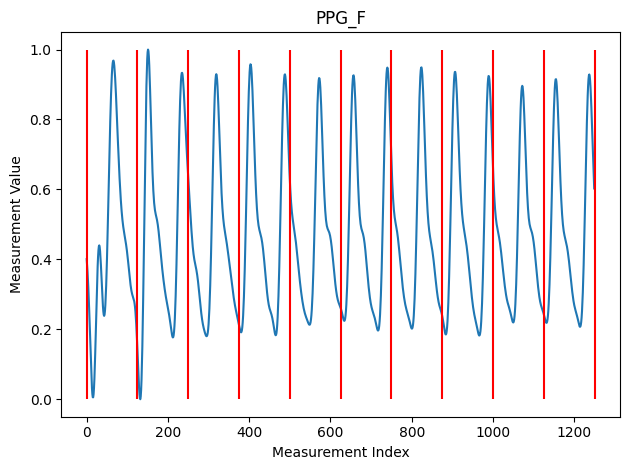

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=1)

plt.subplot(1,1,1)
plt.plot(df['PPG_F'][0])
plt.title("PPG_F")
plt.ylabel('Measurement Value')
plt.xlabel('Measurement Index')
plt.vlines([x for x in range(0,1375,125)],ymin=0,ymax=1,colors='r')

plt.tight_layout()
plt.show()



Red vertical lines signify each full second. 1250 data points in 10 seconds -> every 125 entries is one second

### Creating dataset

In [8]:
class BPDatasetPPG(Dataset):
    """
    PyTorch Dataset for IMDB reviews.

    Args:
        PPG: List of PPG values
        IDs: List of all subject IDs
    """
    def __init__(self, PPG, SubjectIDs):
        self.PPG = PPG
        self.IDs = SubjectIDs

    def __len__(self):
        return len(self.IDs)

    def __getitem__(self, idx):
        tokens = self.PPG[idx]
        indices = range(0, len(tokens))
        length = len(indices)
        return torch.tensor(indices), torch.tensor(self.PPG[idx][0]), length

In [9]:
def classify_raw_abp(abp: float):
    if abp <= 90:
        return 0
    if 90 < abp <= 130:
        return 1
    if abp > 130:
        return 2


abp_classified = df["ABP_Raw"].apply(
    lambda raw_bp_seq: [classify_raw_abp(i) for i in raw_bp_seq]
)

X = np.stack(df["PPG_F"].values, dtype=np.float32)
y = np.stack(abp_classified, dtype=np.float32)

full_dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

# 80/20 split
n_train = int(0.8 * len(full_dataset))
train_dataset, test_dataset = random_split(
    full_dataset,
    [n_train, len(full_dataset) - n_train],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 3

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
)

test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=0
)

# Test a batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  PPG Values: {sample_batch[0].shape}")
print(f"  APB Values: {sample_batch[1].shape}")


Sample batch shapes:
  PPG Values: torch.Size([3, 1250])
  APB Values: torch.Size([3, 1250])


In [10]:
# Quick sanity check: verify tensor shapes before training
gru_model = GRUClassifier(
    input_dim=1,
    hidden_dim=128,
    output_dim=3,
    num_layers=2,
    dropout=0.3
)

sample_seqs, sample_bps = next(iter(train_loader))
print(f"seqs shape:          {sample_seqs.shape}")          # (batch, 1250)
print(f"seqs unsqueezed:     {sample_seqs.unsqueeze(-1).shape}")  # (batch, 1250, 1)
print(f"bps shape:           {sample_bps.shape}")           # (batch, 1250)

with torch.no_grad():
    out = gru_model(sample_seqs.unsqueeze(-1))
print(f"model output shape:  {out.shape}")                   # (batch, 1250, 3)
print(f"argmax predictions:  {out.argmax(dim=2).shape}")     # (batch, 1250)
print("\nAll shapes look correct!")


seqs shape:          torch.Size([3, 1250])
seqs unsqueezed:     torch.Size([3, 1250, 1])
bps shape:           torch.Size([3, 1250])
model output shape:  torch.Size([3, 1250, 3])
argmax predictions:  torch.Size([3, 1250])

All shapes look correct!


### Initialize GRU Model

In [11]:
# ============================================
# Initialize GRU Model
# ============================================
gru_model = GRUClassifier(
    input_dim=1,
    hidden_dim=128,
    output_dim=3,
    num_layers=2,
    dropout=0.3
)

# Count parameters
params_gru = sum(p.numel() for p in gru_model.parameters())
print(f"GRU Parameters: {params_gru:,}")

GRU Parameters: 149,763


In [12]:
# Train GRU
history_gru, time_gru = train_model(
    gru_model, train_loader, test_loader,
    epochs=10, lr=0.001, name="GRU"
)

results['GRU'] = {
    'train_acc': history_gru['train_acc'][-1],
    'val_acc': history_gru['val_acc'][-1],
    'params': params_gru,
    'time': time_gru,
    'history': history_gru
}


Training GRU for 10 epochs...
  Epoch 1 | batch 0/2489 | loss=1.0596
  Epoch 1 | batch 100/2489 | loss=0.6572
  Epoch 1 | batch 200/2489 | loss=0.8415
  Epoch 1 | batch 300/2489 | loss=0.5665
  Epoch 1 | batch 400/2489 | loss=0.5256
  Epoch 1 | batch 500/2489 | loss=0.8647
  Epoch 1 | batch 600/2489 | loss=0.9719
  Epoch 1 | batch 700/2489 | loss=0.4931
  Epoch 1 | batch 800/2489 | loss=0.7119
  Epoch 1 | batch 900/2489 | loss=0.5315
  Epoch 1 | batch 1000/2489 | loss=0.6977
  Epoch 1 | batch 1100/2489 | loss=0.5341
  Epoch 1 | batch 1200/2489 | loss=0.4361
  Epoch 1 | batch 1300/2489 | loss=0.5691
  Epoch 1 | batch 1400/2489 | loss=0.5127
  Epoch 1 | batch 1500/2489 | loss=0.6880
  Epoch 1 | batch 1600/2489 | loss=0.6729
  Epoch 1 | batch 1700/2489 | loss=0.5301
  Epoch 1 | batch 1800/2489 | loss=0.4898
  Epoch 1 | batch 1900/2489 | loss=0.4243
  Epoch 1 | batch 2000/2489 | loss=0.3405
  Epoch 1 | batch 2100/2489 | loss=0.3812
  Epoch 1 | batch 2200/2489 | loss=0.4614
  Epoch 1 | bat

In [15]:
history_gru

{'train_loss': [0.6400731401409476,
  0.5099134265466501,
  0.4635293591616383,
  0.436443922850395,
  0.41104069085138395,
  0.3918230646870231,
  0.3748374005256527,
  0.359353366932413,
  0.34802631749152274,
  0.33884367717945607],
 'train_acc': [70.69298687382802,
  78.32271095633538,
  80.28398607018484,
  81.36068577551568,
  82.62055183498526,
  83.48931154567371,
  84.3030163407447,
  84.96875435306724,
  85.47306723814626,
  85.90101259040986],
 'val_loss': [0.5777528458910234,
  0.4477499895168537,
  0.4570341706754308,
  0.4346742514000658,
  0.3971263210903584,
  0.3625515890016219,
  0.3558422699570656,
  0.3316539173189365,
  0.3636389209696033,
  0.3254661463787047],
 'val_acc': [74.49469737546866,
  80.9685270487413,
  80.68387787895018,
  81.26933047670059,
  83.16987680771291,
  84.81096946973754,
  85.10016068559186,
  86.3262560257097,
  85.6038564542046,
  86.77643277986074]}

### Plot learning curves

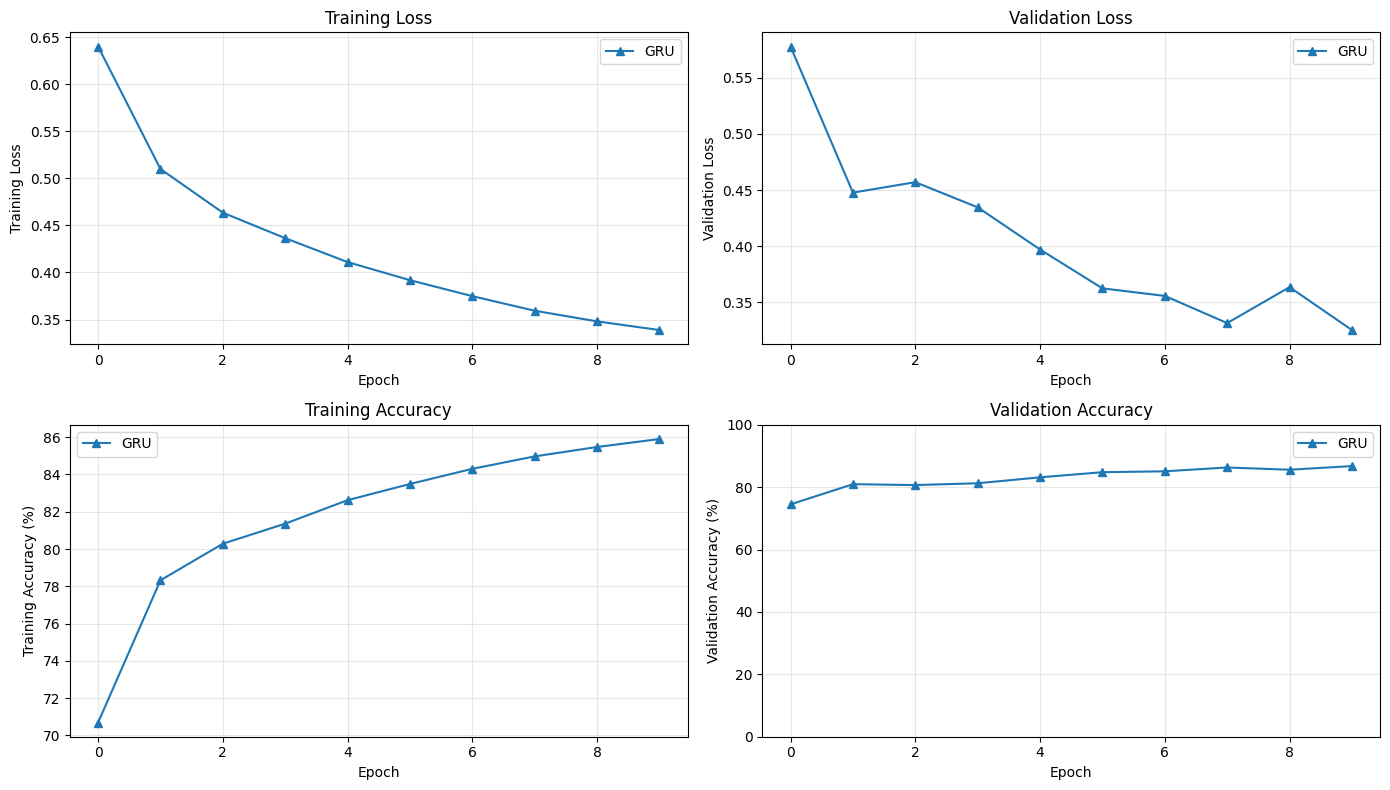

In [21]:
# Plot learning curves comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Training Loss
axes[0][0].plot(history_gru['train_loss'], label='GRU', marker='^')
axes[0][0].set_xlabel('Epoch')
axes[0][0].set_ylabel('Training Loss')
axes[0][0].set_title('Training Loss')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

# Validation Loss
axes[0][1].plot(history_gru['val_loss'], label='GRU', marker='^')
axes[0][1].set_xlabel('Epoch')
axes[0][1].set_ylabel('Validation Loss')
axes[0][1].set_title('Validation Loss')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

# Training Accuracy
axes[1][0].plot(history_gru['train_acc'], label='GRU', marker='^')
axes[1][0].set_xlabel('Epoch')
axes[1][0].set_ylabel('Training Accuracy (%)')
axes[1][0].set_title('Training Accuracy')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

# Validation Accuracy
axes[1][1].plot(history_gru['val_acc'], label='GRU', marker='^')
axes[1][1].set_xlabel('Epoch')
axes[1][1].set_ylabel('Validation Accuracy (%)')
axes[1][1].set_ylim(0,100)
axes[1][1].set_title('Validation Accuracy')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()